# AMAT-4 — Day 2: SEM Noise, Charging, Drift and Edge Effects

Four phenomena in scope (conceptual level only):
- **A. Noise** — fewer detected electrons -> larger statistical variation -> noisier image (Poisson counting).
- **B. Edge effects** — unusual signal strength at boundaries (secant-law edge brightening).
- **C. Charging** — visual manifestation of charge buildup on non-conductive samples.
- **D. Drift/raster artifacts** — sequential scanning creates structured spatial distortion over time.

Working image: dedf11eb6c.png, shape=(512, 696)


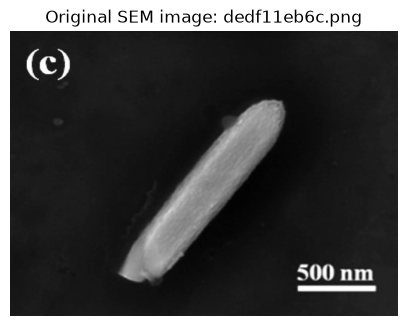

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

DATA_DIR = os.path.join("emps", "images")
files = sorted(os.listdir(DATA_DIR))
rng = np.random.default_rng(0)

fname = rng.choice(files)
img = np.array(Image.open(os.path.join(DATA_DIR, fname)).convert("L")).astype(np.float64)
print(f"Working image: {fname}, shape={img.shape}")

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title(f"Original SEM image: {fname}")
plt.axis("off")
plt.show()


## Analysis 1 — Intensity profiles (row / column)

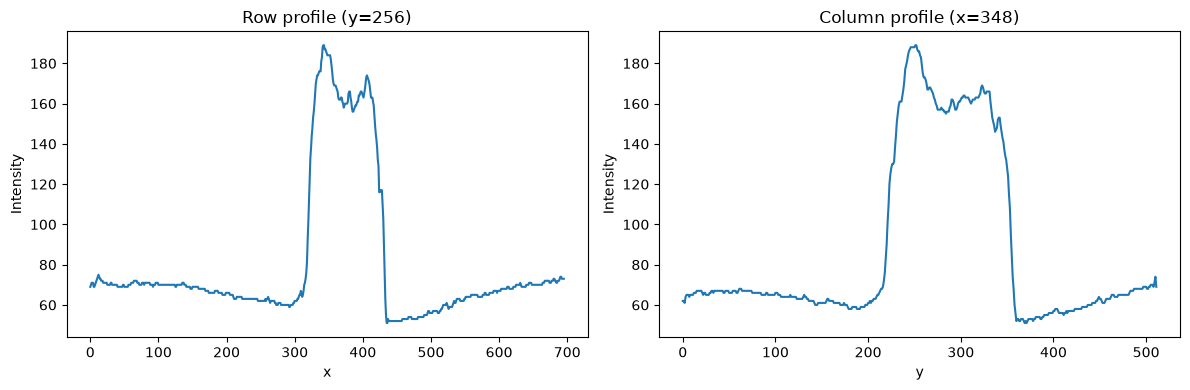

In [2]:
row_y = img.shape[0] // 2
col_x = img.shape[1] // 2

row_profile = img[row_y, :]
col_profile = img[:, col_x]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(row_profile)
axes[0].set_title(f"Row profile (y={row_y})")
axes[0].set_xlabel("x"); axes[0].set_ylabel("Intensity")
axes[1].plot(col_profile)
axes[1].set_title(f"Column profile (x={col_x})")
axes[1].set_xlabel("y"); axes[1].set_ylabel("Intensity")
plt.tight_layout()
plt.show()


## Analysis 2 — Gradient magnitude (Sobel)

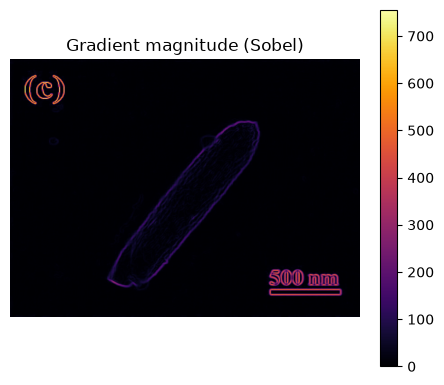

In [3]:
sobel_x = ndimage.sobel(img, axis=1)
sobel_y = ndimage.sobel(img, axis=0)
gradient_magnitude = np.hypot(sobel_x, sobel_y)

plt.figure(figsize=(5, 5))
plt.imshow(gradient_magnitude, cmap="inferno")
plt.title("Gradient magnitude (Sobel)")
plt.axis("off")
plt.colorbar(fraction=0.046)
plt.show()


## Analysis 3 — Local mean / variance

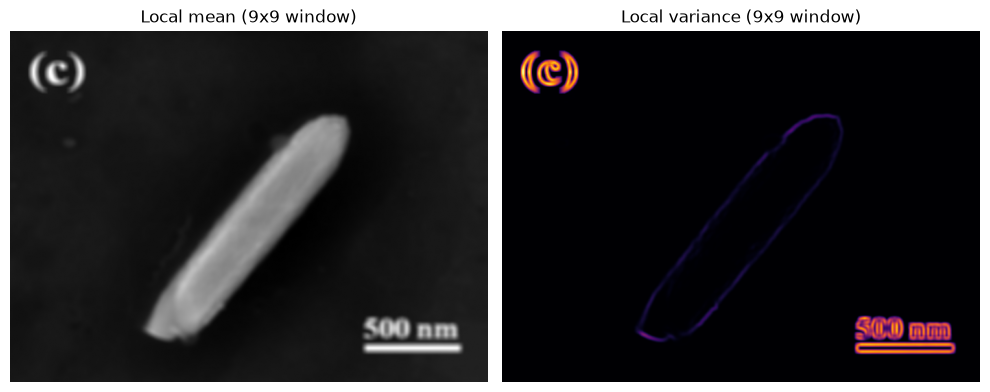

In [4]:
def local_variance(image, window=9):
    mean = ndimage.uniform_filter(image, size=window)
    mean_sq = ndimage.uniform_filter(image**2, size=window)
    return mean_sq - mean**2

local_var = local_variance(img, window=9)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(ndimage.uniform_filter(img, size=9), cmap="gray")
axes[0].set_title("Local mean (9x9 window)")
axes[0].axis("off")
axes[1].imshow(local_var, cmap="inferno")
axes[1].set_title("Local variance (9x9 window)")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## Analysis 4 — FFT magnitude (frequency view)

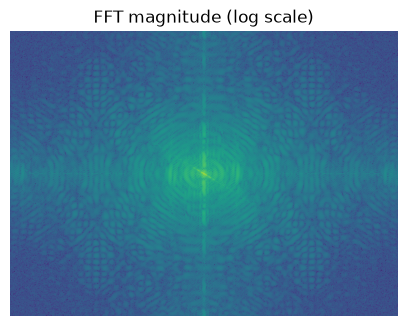

In [5]:
fft = np.fft.fftshift(np.fft.fft2(img))
fft_magnitude = np.log1p(np.abs(fft))

plt.figure(figsize=(5, 5))
plt.imshow(fft_magnitude, cmap="viridis")
plt.title("FFT magnitude (log scale)")
plt.axis("off")
plt.show()


## Mini-experiment — synthetic artifact generation

**These are pedagogical simulations, not validated physical SEM acquisition models.**
They exist only to build intuition for what each artifact looks like, so we can
recognize candidates for it in real EMPS images later.

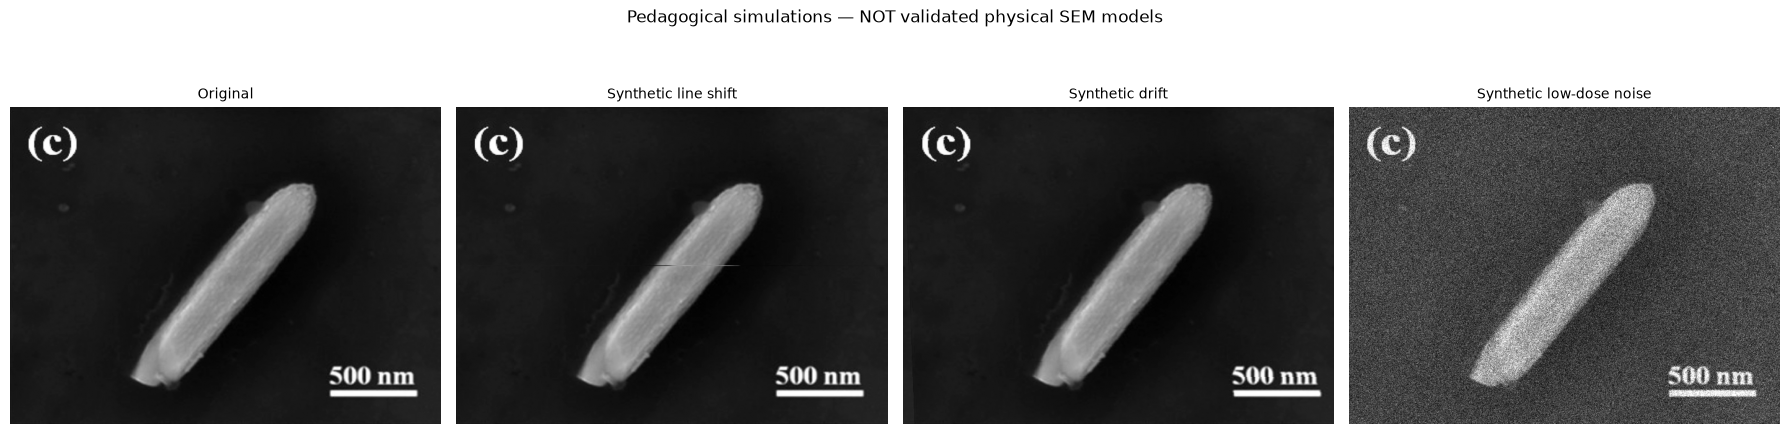

In [6]:
def add_line_shift(image, row, shift_px):
    out = image.copy()
    out[row, :] = np.roll(out[row, :], shift_px)
    return out

def add_drift(image, max_shift_px):
    h = image.shape[0]
    out = np.zeros_like(image)
    for y in range(h):
        shift = int(max_shift_px * y / h)
        out[y, :] = np.roll(image[y, :], shift)
    return out

def add_poisson_noise(image, mean_counts_at_peak):
    scale = image / 255.0
    expected_counts = scale * mean_counts_at_peak
    noisy_counts = rng.poisson(expected_counts)
    noisy = np.clip(noisy_counts / mean_counts_at_peak, 0, 1) * 255.0
    return noisy

line_shift_example = add_line_shift(img, row=img.shape[0] // 2, shift_px=25)
drift_example = add_drift(img, max_shift_px=20)
noise_example = add_poisson_noise(img, mean_counts_at_peak=25)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (title, data) in zip(axes, [
    ("Original", img),
    ("Synthetic line shift", line_shift_example),
    ("Synthetic drift", drift_example),
    ("Synthetic low-dose noise", noise_example),
]):
    ax.imshow(data, cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.suptitle("Pedagogical simulations — NOT validated physical SEM models")
plt.tight_layout()
plt.show()


## Observation / cause / confidence table

Measured directly on the working image analyzed above (`fname`), not generic examples:

| Observation (measured) | Likely cause | Confidence |
|---|---|---|
| Row profile range 51-189, std ~36; largest single-step jump = 14 intensity levels (gradual, not a sharp break) | Real particle edges/topography, not a scan discontinuity | Medium-high |
| Gradient magnitude: mean ~11.5, 95th percentile ~34, max ~755 — a small fraction of pixels carry most of the edge signal | Edge/topography (secant-law electron yield) at particle boundaries | Medium-high |
| Local variance: mean ~129, max ~8173 — highly concentrated in a few small regions rather than spread evenly | Real texture/edges in those regions, not uniform detector noise | Medium |
| FFT: peak magnitude (excluding DC) ~13.9 vs. mean ~6.5 and 99th percentile ~10.6 — a mild, not extreme, standout | No strong periodic scan artifact detected in this specific image | Medium (absence of evidence, not proof of absence) |

**Note:** confidence is capped at medium because we have no acquisition metadata
(dose, scan rate, instrument) for EMPS images — these are pattern-based inferences from
pixel statistics only, not physically verified causes. This mirrors the ground-truth
problem discussed earlier in the project: without a clean reference or known acquisition
parameters, distinguishing "real texture" from "artifact" stays probabilistic. Notably,
this particular image shows **no strong evidence of drift/charging** — the FFT has no
sharp isolated spike, and the row-profile jump is small and gradual rather than a step —
which is itself a useful (if less dramatic) finding: not every image needs an artifact
present to be a valid finding for this notebook.

## Leader review gate

**Q: If the generator reproduces object shape but not these SEM-specific statistics
(noise structure, edge yield curve, scan artifacts), is it successful?**

**A: Not necessarily.** A generator can produce a visually plausible silhouette while
completely missing the counting-noise statistics, the secant-law edge-brightness curve,
or scan-induced artifacts — the numeric baseline established in Day 1 (mean/std/histogram
shape) and the structural analyses here (gradient, local variance, FFT) are exactly the
checks needed to catch that failure mode. Shape correctness and statistical correctness
are separate, both-required criteria.